# SMILE Explainability Analysis: Teacher vs Student Models

**MSc Project: Trustworthy SLMs for Ambient Clinical Scribing**  
**Student: Alireza Rashidi**

This notebook applies the SMILE (Statistical Model-agnostic Interpretability with Local Explanations) method
to compare how different models focus on input words when generating responses.

**Models compared (7 total):**
- Teacher: GPT-4o-mini (via OpenAI API)
- Llama-3.2-3B: Base + Fine-tuned
- Llama-3.2-1B: Base + Fine-tuned

**SMILE Algorithm (Aslansefat et al., 2023):**
1. Generate perturbed versions of the input by randomly dropping words
2. Query each model with original + perturbed inputs
3. Measure semantic distance (WMD) between original and perturbed outputs
4. Fit weighted linear regression: perturbation mask → output similarity
5. Regression coefficients = word importance scores

## 1. Setup & Dependencies

In [ ]:
# Install dependencies (run once)
# !pip install openai sentence-transformers gensim pot scikit-learn matplotlib numpy
# Note: For local models you also need: transformers, torch, unsloth

In [6]:
import gzip
import shutil
from pathlib import Path

models_dir = Path(r"D:\models")
gz_path = models_dir / "GoogleNews-vectors-negative300.bin.gz"
out_path = models_dir / "GoogleNews-vectors-negative300.bin"

models_dir.mkdir(parents=True, exist_ok=True)

if out_path.exists():
    print("Decompressed file already exists:", out_path)
elif gz_path.exists():
    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Decompression complete:", out_path)
else:
    print(f"Missing source file: {gz_path}")
    print("Place the .gz file in D:\\models, or set WORD2VEC_PATH directly to an existing .bin file.")

Decompression complete: D:\models\GoogleNews-vectors-negative300.bin


In [1]:
import os
import numpy as np
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import transforms
from sklearn.linear_model import LinearRegression
from gensim.models import KeyedVectors

# Windows compatibility for local models
os.environ["UNSLOTH_COMPILE_DISABLE"] = "1"
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHDYNAMO_DISABLE"] = "1"

print("Imports complete.")

Imports complete.


## 2. Configuration

Set your paths and API keys here.

In [2]:
# CONFIGURE THESE PATHS

# OpenAI API key for GPT-4o-mini teacher

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OpenAI API key not found. Set OPENAI_API_KEY environment variable.")
print("OpenAI API key configured.")

WORD2VEC_PATH = "D:/models/GoogleNews-vectors-negative300.bin"

# PROJECT ROOT - set this to your ambient-scribe directory
PROJECT_ROOT = "D:/ambient-scribe"

# Local model paths (hf_merged directories - READ ONLY, never modified)
# Uses absolute paths to avoid HuggingFace Hub repo ID confusion
MODEL_CONFIGS = {
    "Phi-3.5 FT": {
        "path": os.path.join(PROJECT_ROOT, "checkpoints/phi35_clinical_scribe/hf_merged"),
        "type": "local",
    },
    "Phi-3.5 Base": {
        # Standard HuggingFace model ID (not unsloth/ prefix)
        "path": "microsoft/Phi-3.5-mini-instruct",
        "type": "local",
    },
    "Llama-3B FT": {
        "path": os.path.join(PROJECT_ROOT, "checkpoints/llama32_3b_clinical_scribe/hf_merged"),
        "type": "local",
    },
    "Llama-3B Base": {
        "path": "meta-llama/Llama-3.2-3B-Instruct",
        "type": "local",
    },
    "Llama-1B FT": {
        "path": os.path.join(PROJECT_ROOT, "checkpoints/llama32_1b_clinical_scribe/hf_merged"),
        "type": "local",
    },
    "Llama-1B Base": {
        "path": "meta-llama/Llama-3.2-1B-Instruct",
        "type": "local",
    },
    "GPT-4o-mini (Teacher)": {
        "path": "gpt-4o-mini",
        "type": "openai",
    },
}

# Verify local model paths exist
for name, cfg in MODEL_CONFIGS.items():
    if cfg["type"] == "local" and not cfg["path"].startswith("meta") and not cfg["path"].startswith("microsoft"):
        if os.path.exists(cfg["path"]):
            print(f"  OK: {name} -> {cfg['path']}")
        else:
            print(f"  WARNING: {name} -> {cfg['path']} NOT FOUND")

# Test sentences for SMILE analysis
TEST_PROMPTS = [
    "What is the meaning of life?",
    "What are the common symptoms of diabetes?",
    "How should hypertension be managed in elderly patients?",
]

# SMILE parameters
NUM_PERTURBATIONS = 64
SEED = 1024
KERNEL_WIDTH = 0.25
MAX_TOKENS = 100

print(f"Configured {len(MODEL_CONFIGS)} models and {len(TEST_PROMPTS)} test prompts.")

OpenAI API key configured.
  OK: Phi-3.5 FT -> D:/ambient-scribe\checkpoints/phi35_clinical_scribe/hf_merged
  OK: Llama-3B FT -> D:/ambient-scribe\checkpoints/llama32_3b_clinical_scribe/hf_merged
  OK: Llama-1B FT -> D:/ambient-scribe\checkpoints/llama32_1b_clinical_scribe/hf_merged
Configured 7 models and 3 test prompts.


## 3. Model Query Functions

Unified interface for querying both OpenAI API (teacher) and local HuggingFace models (students).

In [4]:
# OpenAI API query (for GPT-4o-mini teacher)

def query_openai(text, model="gpt-4o-mini", max_tokens=100):
    """Query OpenAI chat completion API."""
    from openai import OpenAI
    client = OpenAI()
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": text}],
            max_tokens=max_tokens,
            temperature=0,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"


# Local model query (for fine-tuned and base SLMs)

_model_cache = {}

def load_local_model(model_path):
    """Load a local HuggingFace model. Cached after first load."""
    if model_path in _model_cache:
        return _model_cache[model_path]
    
    print(f"  Loading model: {model_path}...")
    
    from transformers import AutoModelForCausalLM, AutoTokenizer
    import torch
    
    is_local = os.path.isdir(model_path)
    path_lower = str(model_path).lower()
    is_phi = "phi" in path_lower
    
    # Problem I faced: For Phi-3.5: try WITHOUT trust_remote_code first
    # Newer transformers has built-in Phi-3 support that avoids the
    # DynamicCache.seen_tokens bug in Microsoft's custom modeling_phi3.py
    if is_phi:
        try:
            print("  Attempting to load Phi without custom code (built-in support)...")
            tokenizer = AutoTokenizer.from_pretrained(
                model_path, local_files_only=is_local,
            )
            model = AutoModelForCausalLM.from_pretrained(
                model_path,
                torch_dtype=torch.float16,
                device_map="auto",
                local_files_only=is_local,
                attn_implementation="eager",
            )
            model.eval()
            _model_cache[model_path] = (model, tokenizer)
            print(f"  Loaded: {model_path} (built-in Phi support)")
            return model, tokenizer
        except Exception as e:
            print(f"  Built-in load failed ({e}), trying with trust_remote_code...")
            # Fall through to trust_remote_code path
    
    tokenizer = AutoTokenizer.from_pretrained(
        model_path,
        local_files_only=is_local,
        trust_remote_code=True,
    )
    
    load_kwargs = {
        "device_map": "auto",
        "local_files_only": is_local,
        "trust_remote_code": True,
        "attn_implementation": "eager",
    }
    
    # Llama uses torch_dtype; some custom models use dtype
    load_kwargs["torch_dtype"] = torch.float16
    
    model = AutoModelForCausalLM.from_pretrained(model_path, **load_kwargs)
    model.eval()
    
    _model_cache[model_path] = (model, tokenizer)
    print(f"  Loaded: {model_path} (local={is_local})")
    return model, tokenizer


def query_local(text, model_path, max_tokens=100):
    """Query a local HuggingFace model using its chat template."""
    import torch
    
    model, tokenizer = load_local_model(model_path)
    
    messages = [{"role": "user", "content": text}]
    
    if hasattr(tokenizer, 'apply_chat_template'):
        input_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    else:
        input_text = text
    
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.1,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    generated_tokens = outputs[0][input_len:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    return response


# Unified query function

def query_model(text, model_name, model_config):
    """Query any model using the appropriate backend."""
    if model_config["type"] == "openai":
        return query_openai(text, model=model_config["path"], max_tokens=MAX_TOKENS)
    else:
        return query_local(text, model_config["path"], max_tokens=MAX_TOKENS)


print("Query functions defined.")


Query functions defined.


## 4. SMILE Core Algorithm

The SMILE method:
1. **Perturb** the input by randomly including/excluding words
2. **Query** the model with each perturbation
3. **Measure** semantic distance between original and perturbed outputs (WMD)
4. **Regress** perturbation masks → output similarity with distance-based kernel weights
5. **Coefficients** = per-word importance scores

In [5]:
# Load Word2Vec model for WMD computation
print("Loading Word2Vec model (this takes ~1 minute)...")
w2v_model = KeyedVectors.load_word2vec_format(WORD2VEC_PATH, binary=True)
print(f"Word2Vec loaded: {len(w2v_model)} words")

Loading Word2Vec model (this takes ~1 minute)...
Word2Vec loaded: 3000000 words


In [ ]:

# Test Word2Vec model and WMD computation
# Run this cell to verify everything works before the main loop

import re

# Test : Check if basic words are in vocabulary
test_words = ['what', 'is', 'the', 'meaning', 'of', 'life', 'life?', 'What', 'Life']
print('=== Vocabulary Check ===')
for w in test_words:
    print(f'  "{w}" in vocab: {w in w2v_model}')

# Test : Check clean_for_wmd from the SMILE functions
def test_clean(text, model):
    words = re.findall(r'[a-zA-Z]+', text.lower())
    cleaned = [w for w in words if w in model]
    return cleaned

print('\n=== Text Cleaning ===')
texts = ['What is the meaning of life?', 'meaning of', 'What life?', 'the is']
for t in texts:
    cleaned = test_clean(t, w2v_model)
    print(f'  "{t}" -> {cleaned}')

# Test  Compute WMD between two cleaned texts
print('\n=== WMD Test ===')
t1 = test_clean('What is the meaning of life?', w2v_model)
t2 = test_clean('meaning of life', w2v_model)
t3 = test_clean('the is', w2v_model)
print(f'  t1 = {t1}')
print(f'  t2 = {t2}')
print(f'  t3 = {t3}')

if t1 and t2:
    d = w2v_model.wmdistance(t1, t2)
    print(f'  WMD(t1, t2) = {d}')
else:
    print('  ERROR: t1 or t2 is empty after cleaning!')

if t1 and t3:
    d = w2v_model.wmdistance(t1, t3)
    print(f'  WMD(t1, t3) = {d}')
else:
    print('  ERROR: t1 or t3 is empty after cleaning!')


# Test 4: Check the type of w2v_model
print(f'\n=== Model Info ===')
print(f'  Type: {type(w2v_model)}')
print(f'  Vocab size: {len(w2v_model)}')
print(f'  Vector size: {w2v_model.vector_size}')


=== Vocabulary Check ===
  "what" in vocab: True
  "is" in vocab: True
  "the" in vocab: True
  "meaning" in vocab: True
  "of" in vocab: False
  "life" in vocab: True
  "life?" in vocab: False
  "What" in vocab: True
  "Life" in vocab: True

=== Text Cleaning ===
  "What is the meaning of life?" -> ['what', 'is', 'the', 'meaning', 'life']
  "meaning of" -> ['meaning']
  "What life?" -> ['what', 'life']
  "the is" -> ['the', 'is']

=== WMD Test ===
  t1 = ['what', 'is', 'the', 'meaning', 'life']
  t2 = ['meaning', 'life']
  t3 = ['the', 'is']
  WMD(t1, t2) = 0.7665750898861433
  WMD(t1, t3) = 0.7452362213723167

=== Model Info ===
  Type: <class 'gensim.models.keyedvectors.KeyedVectors'>
  Vocab size: 3000000
  Vector size: 300


In [ ]:
import re

def perturb_text(text_list, perturbation, rng):
    """Apply a binary perturbation mask and keep at least two non-empty words."""
    selected = [item for item, flag in zip(text_list, perturbation) if flag == 1 and item.strip()]
    
    # Ensure at least 2 words are selected to avoid empty prompts that cause WMD issues
    if len(selected) < 2:
        available_words = [item for item in text_list if item.strip()]
        additional_words = rng.choice(available_words, 2, replace=False)
        selected = list(set(selected + list(additional_words)))
    else:
        selected = list(set(selected))
    return selected

def generate_perturbations(words, num_perturb=64, seed=1024):
    """
    Generate random binary perturbation masks for the input words.
    Each mask is a tuple of 0/1 indicating whether each word is included.
    """
    rng = np.random.default_rng(seed)
    num_words = len(words)
    
    unique_perturbations = set()
    perturbations = []
    perturbed_texts = []
    
    attempts = 0
    max_attempts = num_perturb * 10
    
    while len(unique_perturbations) < num_perturb and attempts < max_attempts:
        p = tuple(rng.binomial(1, 0.5, size=num_words))
        if p not in unique_perturbations and sum(p) > 0:
            unique_perturbations.add(p)
            selected = perturb_text(words, p, rng)
            perturbations.append(p)
            perturbed_texts.append(' '.join(selected))
        attempts += 1
    
    while len(perturbations) < num_perturb:
        p = rng.choice(list(unique_perturbations))
        selected = perturb_text(words, p, rng)
        perturbations.append(tuple(p))
        perturbed_texts.append(' '.join(selected))
    
    return perturbations, perturbed_texts


def clean_for_wmd(text, w2v_model):
    """
    Clean text for WMD computation:
    - Strip punctuation from words (life? -> life)
    - Lowercase
    - Remove words not in Word2Vec vocabulary
    
    Without this, words like "life?" cause WMD to return infinity
    because they are not in the Word2Vec vocabulary.
    """
    words = re.findall(r"[a-zA-Z]+", text.lower())
    return [w for w in words if w in w2v_model]


def compute_smile_scores(prompt, model_name, model_config, w2v_model,
                         num_perturb=64, seed=1024, kernel_width=0.25):
    """
    Important:
    Run the full SMILE pipeline for a single model and prompt.
    
    Algorithm (Aslansefat et al., 2023):
    1. Query model with original prompt
    2. Generate N perturbed prompts by randomly dropping words
    3. Query model with each perturbation
    4. Compute WMD between original output and each perturbed output
    5. Compute WMD between original prompt and each perturbed prompt
    6. Use prompt distances as kernel weights (closer = higher weight)
    7. Fit weighted linear regression: perturbation mask -> output similarity
    8. Coefficients = per-word importance scores
    """
    words = prompt.split()
    
    # Step 1 Get original output
    print(f"    Querying original prompt...")
    original_output = query_model(prompt, model_name, model_config)
    print(f"    Original output: {original_output[:100]}...")
    
    if not original_output or original_output.startswith("Error:"):
        raise ValueError(f"Model returned error: {original_output[:200]}")
    
    # Step 2 Generate perturbations
    perturbations, perturbed_texts = generate_perturbations(words, num_perturb, seed)
    
    # Step 3 Query model with each perturbation
    print(f"    Querying {len(perturbed_texts)} perturbations...")
    perturbed_outputs = []
    for i, pt in enumerate(perturbed_texts):
        output = query_model(pt, model_name, model_config)
        perturbed_outputs.append(output)
        if (i + 1) % 16 == 0:
            print(f"      {i+1}/{len(perturbed_texts)} done")
    
    # Step 4: Compute WMD between original output and each perturbed output
    # Clean text first: strip punctuation, lowercase, filter OOV words
    # This prevents inf distances from words like "life?" not in Word2Vec
    epsilon = 1e-8
    orig_clean = clean_for_wmd(original_output, w2v_model)
    
    wmd_output_scores = []
    for po in perturbed_outputs:
        po_clean = clean_for_wmd(po, w2v_model)
        if not orig_clean or not po_clean:
            wmd_output_scores.append(10.0)
            continue
        try:
            dist = w2v_model.wmdistance(orig_clean, po_clean)
            if np.isinf(dist) or np.isnan(dist):
                dist = 10.0
        except Exception:
            dist = 10.0
        wmd_output_scores.append(dist)
    
    print(f"    WMD output distances: min={min(wmd_output_scores):.3f}, "
          f"max={max(wmd_output_scores):.3f}, "
          f"mean={np.mean(wmd_output_scores):.3f}")
    
    # Convert WMD to similarity (inverse, scaled to [0,1])
    inverse_wmd = [1.0 / (d + epsilon) for d in wmd_output_scores]
    min_inv = min(inverse_wmd)
    max_inv = max(inverse_wmd)
    range_inv = max_inv - min_inv if max_inv > min_inv else 1.0
    similarities = [(v - min_inv) / range_inv for v in inverse_wmd]
    
    # Step 5: Compute WMD between original prompt and each perturbed prompt
    prompt_clean = clean_for_wmd(prompt, w2v_model)
    
    wmd_prompt_scores = []
    for pt in perturbed_texts:
        pt_clean = clean_for_wmd(pt, w2v_model)
        if not prompt_clean or not pt_clean:
            wmd_prompt_scores.append(10.0)
            continue
        try:
            dist = w2v_model.wmdistance(prompt_clean, pt_clean)
            if np.isinf(dist) or np.isnan(dist):
                dist = 10.0
        except Exception:
            dist = 10.0
        wmd_prompt_scores.append(dist)
    
    print(f"    WMD prompt distances: min={min(wmd_prompt_scores):.3f}, "
          f"max={max(wmd_prompt_scores):.3f}, "
          f"mean={np.mean(wmd_prompt_scores):.3f}")
    
    # Step 6: Compute kernel weights (locality)
    # Closer perturbations to the original prompt get higher weight
    distance_values = np.array(wmd_prompt_scores)
    weights = np.sqrt(np.exp(-(distance_values ** 2) / (kernel_width ** 2)))
    
    # Safety: if all weights are zero, use uniform weights
    # This can happen if all perturbations are very far from the original
    if weights.sum() < 1e-10:
        print(f"    WARNING: All kernel weights near zero. "
              f"Falling back to distance-based weights.")
        # Use inverse distance as weights instead of exponential kernel
        weights = 1.0 / (distance_values + epsilon)
    
    # Normalise weights to sum to 1 (not strictly required by sklearn
    # but makes the weights interpretable)
    weights = weights / weights.sum()
    
    print(f"    Weights: min={weights.min():.4f}, max={weights.max():.4f}, "
          f"nonzero={np.sum(weights > 1e-10)}/{len(weights)}")
    
    # Step 7: Fit weighted linear regression
    X = np.vstack(perturbations)
    y = np.array(similarities)
    
    linear_model = LinearRegression()
    linear_model.fit(X=X, y=y, sample_weight=weights)
    coefficients = linear_model.coef_
    
    print(f"    Coefficients: {dict(zip(words, np.round(coefficients, 4)))}")
    
    metadata = {
        "original_output": original_output,
        "num_perturbations": len(perturbations),
        "r_squared": linear_model.score(X, y, sample_weight=weights),
        "wmd_output_stats": {
            "min": float(min(wmd_output_scores)),
            "max": float(max(wmd_output_scores)),
            "mean": float(np.mean(wmd_output_scores)),
        },
    }
    
    return words, coefficients, metadata


print("SMILE functions defined.")


SMILE functions defined.


## 5. Heatmap Visualisation

In [8]:

# Used some code from the supervisor's original visualisation method, but heavily modified to show scores below each word and support multiple lines for long prompts.

def plot_text_heatmap(words, scores, title="", width=10, height=0.4, verbose=0, 
                      max_word_per_line=20, word_spacing=20, score_fontsize=10, 
                      save_path=None):
    """
    Plot a text heatmap using the supervisor's original method.
    Words are coloured by SMILE importance scores.
    Blue = positive importance, Red = negative importance, White = neutral.
    """
    fig = plt.figure(figsize=(width, height))
    ax = plt.gca()
    ax.set_title(title, loc='left')
    cmap = plt.cm.ScalarMappable(cmap=plt.cm.bwr)
    cmap.set_clim(0, 1)
    canvas = ax.figure.canvas
    t = ax.transData
    
    max_abs = np.max(np.abs(scores))
    if max_abs == 0:
        max_abs = 1.0
    normalized_scores = 0.5 * scores / max_abs + 0.5
    
    loc_y = -0.2
    for i, (token, score) in enumerate(zip(words, scores)):
        *rgb, _ = cmap.to_rgba(normalized_scores[i], bytes=True)
        color = '#%02x%02x%02x' % tuple(rgb)
        text = ax.text(0.0, loc_y, token, 
                       bbox={'facecolor': color, 'pad': 5.0, 'linewidth': 1, 
                             'boxstyle': 'round,pad=0.5'}, 
                       transform=t, fontsize=14)
        text.draw(canvas.get_renderer())
        ex = text.get_window_extent()
        score_text = ax.text(0.01, loc_y - 1, f"{score:.2f}", 
                             transform=t, fontsize=score_fontsize, ha='center')
        score_text.draw(canvas.get_renderer())
        if (i+1) % max_word_per_line == 0:
            loc_y -= 2.5
            t = ax.transData
        else:
            t = transforms.offset_copy(text._transform, x=ex.width + word_spacing, units='dots')
    if verbose == 0:
        ax.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


def plot_comparison_bar(all_results, prompt, save_path=None):
    """
    Side-by-side bar chart comparing word importance across all models.
    """
    words = prompt.split()
    model_names = list(all_results.keys())
    n_models = len(model_names)
    n_words = len(words)
    
    fig, ax = plt.subplots(figsize=(max(14, n_words * 2.5), 6))
    x = np.arange(n_words)
    w = 0.8 / max(n_models, 1)
    colors = plt.cm.Set2(np.linspace(0, 1, max(n_models, 3)))
    
    for i, model_name in enumerate(model_names):
        coeffs = all_results[model_name]["coefficients"]
        ax.bar(x + i * w, coeffs, w, label=model_name, color=colors[i],
               edgecolor='black', linewidth=0.3)
    
    ax.set_xlabel('Input Word', fontsize=12)
    ax.set_ylabel('SMILE Importance Score', fontsize=12)
    ax.set_title(f'SMILE Word Importance Comparison\nPrompt: "{prompt}"',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x + w * (n_models - 1) / 2)
    ax.set_xticklabels(words, fontsize=11)
    ax.legend(fontsize=8, ncol=2, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("Visualisation functions defined.")


Visualisation functions defined.


## 6. Run SMILE Analysis

Run one model at a time to manage GPU memory. After running a local model, you can free its memory before loading the next.

In [ ]:
import gc
import torch

def free_gpu_memory():
    """Free GPU memory between model runs."""
    global _model_cache
    # Delete model references first
    
    
    for key in list(_model_cache.keys()):
        model, tokenizer = _model_cache[key]
        del model
        del tokenizer
    _model_cache.clear()
    gc.collect()
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except RuntimeError as e:
        # CUDA device-side assert can corrupt the context
        # Just continue — memory will be freed when next model loads
        print(f"  Warning: CUDA cache clear failed ({e}), continuing...")
    print("  GPU memory freed.")


In [10]:
list(MODEL_CONFIGS.keys())

['Phi-3.5 FT',
 'Phi-3.5 Base',
 'Llama-3B FT',
 'Llama-3B Base',
 'Llama-1B FT',
 'Llama-1B Base',
 'GPT-4o-mini (Teacher)']

In [11]:
models = list(MODEL_CONFIGS.keys())
# Run all models on the first prompt by default.
# Change these to control what runs:
# MODELS_TO_RUN = ["Phi-3.5 Base", "Llama-3B Base", "Llama-1B Base"]

MODELS_TO_RUN = ["Llama-3B FT", "Llama-1B FT", "Llama-3B Base", "Llama-1B Base", "GPT-4o-mini (Teacher)"] 

PROMPTS_TO_RUN = TEST_PROMPTS[:1]  # Start with first prompt; expand later

print(f"Will run {len(MODELS_TO_RUN)} models on {len(PROMPTS_TO_RUN)} prompt(s)")
print(f"Total API/inference calls: ~{len(MODELS_TO_RUN) * len(PROMPTS_TO_RUN) * (NUM_PERTURBATIONS + 1)}")

Will run 5 models on 1 prompt(s)
Total API/inference calls: ~325


In [ ]:
# main loop: run SMILE analysis for each model and prompt, store results in a dictionary for later visualisation and comparison

all_results = {}  # {prompt: {model_name: {words, coefficients, metadata}}}

# for each prompt, run all models and store results
for prompt in PROMPTS_TO_RUN:
    print(f"\n{'='*70}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*70}")
    
    prompt_results = {}
    
    for model_name in MODELS_TO_RUN:
        config = MODEL_CONFIGS[model_name]
        print(f"\n  --- {model_name} ({config['type']}) ---")
        
        try:
            start = time.time()
            words, coefficients, metadata = compute_smile_scores(
                prompt, model_name, config, w2v_model,
                num_perturb=NUM_PERTURBATIONS, seed=SEED, kernel_width=KERNEL_WIDTH,
            )
            elapsed = time.time() - start
            
            prompt_results[model_name] = {
                "words": words,
                "coefficients": coefficients,
                "metadata": metadata,
                "time_seconds": elapsed,
            }
            print(f"    Completed in {elapsed:.1f}s (R²={metadata['r_squared']:.3f})")
            
        except Exception as e:
            print(f"    ERROR: {e}")
            import traceback
            traceback.print_exc()
            prompt_results[model_name] = {"error": str(e)}
        
        # Free GPU memory between local models
        if config['type'] == 'local':
            try:
                free_gpu_memory()
            except Exception:
                print("  Warning: GPU cleanup failed, continuing...")
    
    all_results[prompt] = prompt_results

print("\n\nAll analyses complete!")



PROMPT: What is the meaning of life?

  --- Llama-3B FT (local) ---
    Querying original prompt...
  Loading model: D:/ambient-scribe\checkpoints/llama32_3b_clinical_scribe/hf_merged...


c:\Users\943533\AppData\Local\miniconda3\envs\smile_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The tokenizer you are loading from 'D:/ambient-scribe\checkpoints/llama32_3b_clinical_scribe/hf_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 254/254 [00:11<00:00, 22.60it/s]


  Loaded: D:/ambient-scribe\checkpoints/llama32_3b_clinical_scribe/hf_merged (local=True)
    Original output: The question of the meaning of life is one of the most profound and debated topics in human history....
    Querying 64 perturbations...
      16/64 done
      32/64 done
      48/64 done
      64/64 done
    WMD output distances: min=0.408, max=1.212, mean=1.000
    WMD prompt distances: min=0.000, max=1.032, mean=0.567
    Weights: min=0.0000, max=0.0847, nonzero=64/64
    Coefficients: {'What': 0.0958, 'is': 0.1481, 'the': 0.0673, 'meaning': 0.2814, 'of': -0.1249, 'life?': 0.222}
    Completed in 116.8s (R²=0.407)
  GPU memory freed.

  --- Llama-1B FT (local) ---
    Querying original prompt...
  Loading model: D:/ambient-scribe\checkpoints/llama32_1b_clinical_scribe/hf_merged...


The tokenizer you are loading from 'D:/ambient-scribe\checkpoints/llama32_1b_clinical_scribe/hf_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Loading weights: 100%|██████████| 146/146 [00:36<00:00,  3.95it/s]


  Loaded: D:/ambient-scribe\checkpoints/llama32_1b_clinical_scribe/hf_merged (local=True)
    Original output: The question of the meaning of life is one of the oldest and most profound mysteries in human existe...
    Querying 64 perturbations...
      16/64 done
      32/64 done
      48/64 done
      64/64 done
    WMD output distances: min=0.328, max=1.160, mean=0.849
    WMD prompt distances: min=0.000, max=1.032, mean=0.567
    Weights: min=0.0000, max=0.0847, nonzero=64/64
    Coefficients: {'What': 0.0012, 'is': -0.0898, 'the': 0.0466, 'meaning': 0.0528, 'of': 0.2726, 'life?': 0.2032}
    Completed in 120.0s (R²=0.565)
  GPU memory freed.

  --- Llama-3B Base (local) ---
    Querying original prompt...
  Loading model: meta-llama/Llama-3.2-3B-Instruct...


Loading weights: 100%|██████████| 254/254 [00:02<00:00, 98.82it/s] 


  Loaded: meta-llama/Llama-3.2-3B-Instruct (local=False)
    Original output: The meaning of life is a complex and subjective question that has been debated by philosophers, theo...
    Querying 64 perturbations...
      16/64 done
      32/64 done
      48/64 done
      64/64 done
    WMD output distances: min=0.455, max=1.153, mean=0.994
    WMD prompt distances: min=0.000, max=1.032, mean=0.567
    Weights: min=0.0000, max=0.0847, nonzero=64/64
    Coefficients: {'What': 0.0028, 'is': -0.0165, 'the': 0.0304, 'meaning': 0.3246, 'of': 0.1295, 'life?': 0.2668}
    Completed in 115.5s (R²=0.611)
  GPU memory freed.

  --- Llama-1B Base (local) ---
    Querying original prompt...
  Loading model: meta-llama/Llama-3.2-1B-Instruct...


Loading weights: 100%|██████████| 146/146 [00:01<00:00, 138.36it/s]


  Loaded: meta-llama/Llama-3.2-1B-Instruct (local=False)
    Original output: The question of the meaning of life is a profound and complex one that has been debated by philosoph...
    Querying 64 perturbations...
      16/64 done
      32/64 done
      48/64 done
      64/64 done
    WMD output distances: min=0.506, max=1.176, mean=0.926
    WMD prompt distances: min=0.000, max=1.032, mean=0.567
    Weights: min=0.0000, max=0.0847, nonzero=64/64
    Coefficients: {'What': 0.0278, 'is': -0.059, 'the': 0.0006, 'meaning': 0.1124, 'of': 0.1078, 'life?': 0.1958}
    Completed in 88.0s (R²=0.764)
  GPU memory freed.

  --- GPT-4o-mini (Teacher) (openai) ---
    Querying original prompt...
    Original output: The meaning of life is a profound and philosophical question that has been explored by thinkers, the...
    Querying 64 perturbations...
      16/64 done
      32/64 done
      48/64 done
      64/64 done
    WMD output distances: min=0.492, max=1.163, mean=0.974
    WMD prompt distan

## 7. Visualise Results


Prompt: What is the meaning of life?


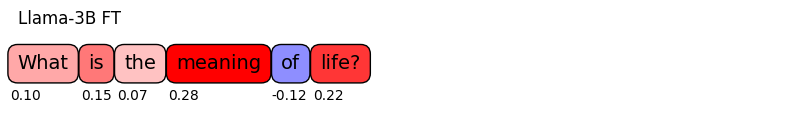

  Llama-3B FT: {'What': 0.096, 'is': 0.148, 'the': 0.067, 'meaning': 0.281, 'of': -0.125, 'life?': 0.222}


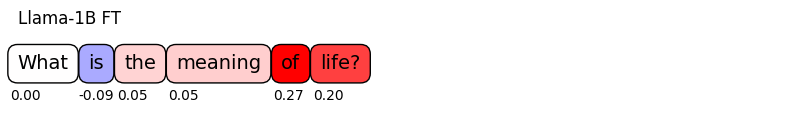

  Llama-1B FT: {'What': 0.001, 'is': -0.09, 'the': 0.047, 'meaning': 0.053, 'of': 0.273, 'life?': 0.203}


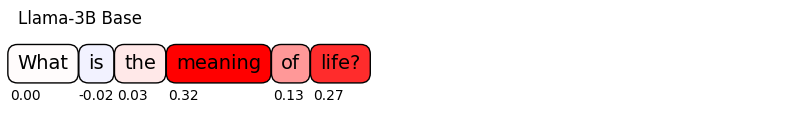

  Llama-3B Base: {'What': 0.003, 'is': -0.017, 'the': 0.03, 'meaning': 0.325, 'of': 0.13, 'life?': 0.267}


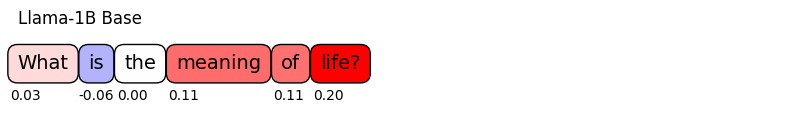

  Llama-1B Base: {'What': 0.028, 'is': -0.059, 'the': 0.001, 'meaning': 0.112, 'of': 0.108, 'life?': 0.196}


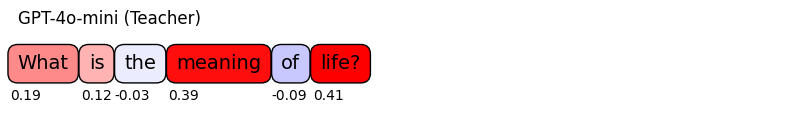

  GPT-4o-mini (Teacher): {'What': 0.187, 'is': 0.121, 'the': -0.031, 'meaning': 0.388, 'of': -0.089, 'life?': 0.411}


In [13]:
# word heatmaps: One per model per prompt

output_dir = Path("./smile_results")
output_dir.mkdir(exist_ok=True)

for prompt, prompt_results in all_results.items():
    print(f"\nPrompt: {prompt}")
    print("=" * 60)
    
    for model_name, result in prompt_results.items():
        if "error" in result:
            print(f"  {model_name}: SKIPPED (error)")
            continue
        
        words = result["words"]
        coeffs = result["coefficients"]
        
        safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '')
        safe_prompt = prompt[:30].replace(' ', '_').replace('?', '')
        save_path = output_dir / f"heatmap_{safe_name}_{safe_prompt}.png"
        
        plot_text_heatmap(
            words, coeffs,
            title=f"{model_name}",
            save_path=str(save_path),
        )
        
        print(f"  {model_name}: {dict(zip(words, np.round(coeffs, 3)))}")

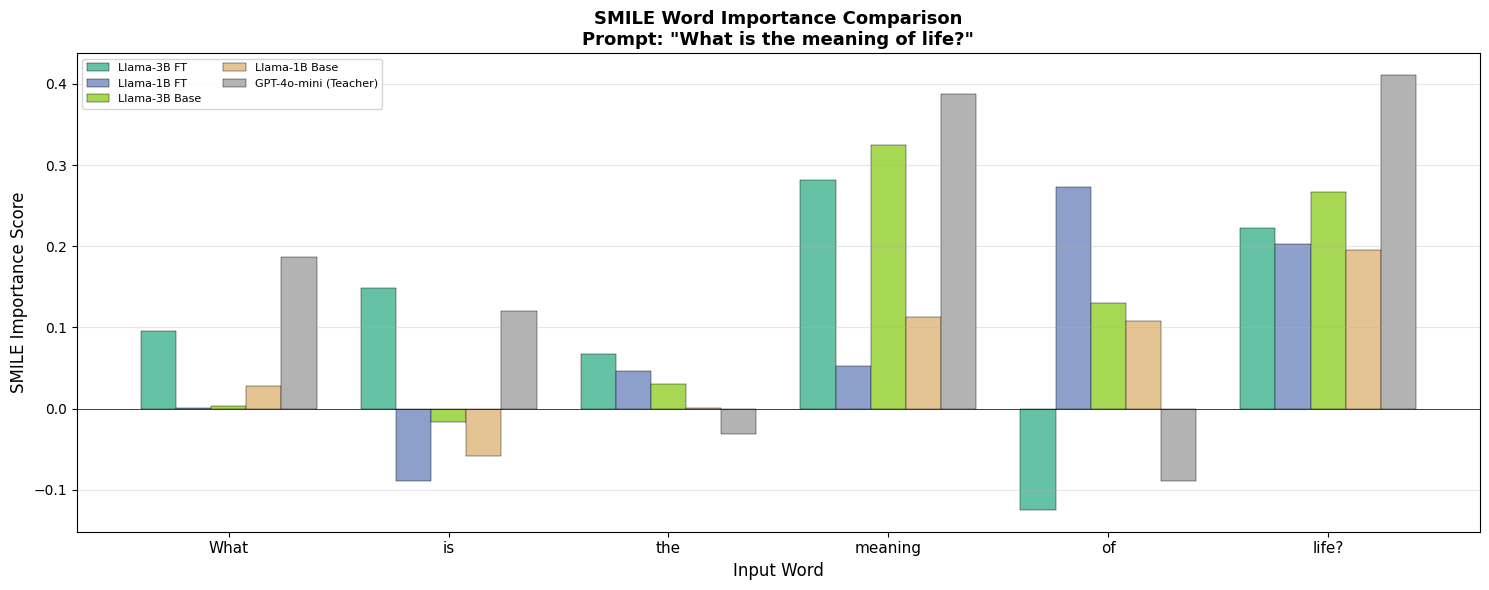

In [14]:

# Comparison barcharts: All models on same plot

for prompt, prompt_results in all_results.items():
    # Filter errors
    valid_results = {k: v for k, v in prompt_results.items() if "error" not in v}
    
    if len(valid_results) >= 2:
        safe_prompt = prompt[:30].replace(' ', '_').replace('?', '')
        save_path = output_dir / f"comparison_{safe_prompt}.png"
        plot_comparison_bar(valid_results, prompt, save_path=str(save_path))

## 8. Quantitative Comparison

Compute correlation between models' word importance rankings to see if they focus on the same words.

In [ ]:
from scipy.stats import spearmanr, pearsonr

for prompt, prompt_results in all_results.items():
    print(f"\nPrompt: \"{prompt}\"")
    print("-" * 70)
    
    
    valid = {k: v for k, v in prompt_results.items() if "error" not in v}
    model_names = list(valid.keys())
    
    if len(model_names) < 2:
        print("  Not enough models for comparison.")
        continue
    
    # Build coefficient matrix
    words = valid[model_names[0]]["words"]
    
    # Print summary table
    print(f"\n  {'Word':<15}", end="")
    for mn in model_names:
        short = mn[:12]
        print(f"{short:>13}", end="")
    print()
    print("  " + "-" * (15 + 13 * len(model_names)))
    
    for wi, word in enumerate(words):
        print(f"  {word:<15}", end="")
        for mn in model_names:
            c = valid[mn]["coefficients"][wi]
            print(f"{c:>13.4f}", end="")
        print()
    
    # Pairwise correlations
    print(f"\n  Pairwise Spearman Correlations:")
    print(f"  {'':20}", end="")
    for mn in model_names:
        print(f"{mn[:12]:>13}", end="")
    print()
    
    for i, mn_i in enumerate(model_names):
        print(f"  {mn_i[:20]:<20}", end="")
        for j, mn_j in enumerate(model_names):
            if i == j:
                print(f"{'1.000':>13}", end="")
            else:
                c_i = valid[mn_i]["coefficients"]
                c_j = valid[mn_j]["coefficients"]
                rho, _ = spearmanr(c_i, c_j)
                print(f"{rho:>13.3f}", end="")
        print()
    
    # Highlight: Teacher vs Fine-tuned comparison
    teacher_key = [k for k in model_names if "Teacher" in k or "GPT" in k]
    ft_keys = [k for k in model_names if "FT" in k]
    
    if teacher_key and ft_keys:
        print(f"\n  Teacher vs Fine-tuned Student Correlations:")
        t_coeffs = valid[teacher_key[0]]["coefficients"]
        for fk in ft_keys:
            s_coeffs = valid[fk]["coefficients"]
            rho, p = spearmanr(t_coeffs, s_coeffs)
            print(f"    {teacher_key[0]} vs {fk}: rho={rho:.3f} (p={p:.4f})")
    
    # Highlight: Base vs Fine-tuned comparison
    base_keys = [k for k in model_names if "Base" in k]
    if base_keys and ft_keys:
        print(f"\n  Base vs Fine-tuned (same architecture) Correlations:")
        for bk in base_keys:
            arch = bk.split(" Base")[0]
            matching_ft = [fk for fk in ft_keys if arch in fk]
            if matching_ft:
                b_coeffs = valid[bk]["coefficients"]
                f_coeffs = valid[matching_ft[0]]["coefficients"]
                rho, p = spearmanr(b_coeffs, f_coeffs)
                print(f"    {bk} vs {matching_ft[0]}: rho={rho:.3f} (p={p:.4f})")


Prompt: "What is the meaning of life?"
----------------------------------------------------------------------

  Word             Llama-3B FT  Llama-1B FT Llama-3B Bas Llama-1B Bas GPT-4o-mini 
  --------------------------------------------------------------------------------
  What                  0.0958       0.0012       0.0028       0.0278       0.1870
  is                    0.1481      -0.0898      -0.0165      -0.0590       0.1209
  the                   0.0673       0.0466       0.0304       0.0006      -0.0313
  meaning               0.2814       0.0528       0.3246       0.1124       0.3881
  of                   -0.1249       0.2726       0.1295       0.1078      -0.0887
  life?                 0.2220       0.2032       0.2668       0.1958       0.4111

  Pairwise Spearman Correlations:
                        Llama-3B FT  Llama-1B FT Llama-3B Bas Llama-1B Bas GPT-4o-mini 
  Llama-3B FT                 1.000       -0.143        0.429        0.429        0.886
  Llama-1B FT

In [ ]:
# Quick diagnostic: compare teacher similarity with several metrics
import numpy as np
from scipy.stats import spearmanr, pearsonr

prompt_key = next(iter(all_results))
valid_results = {k: v for k, v in all_results[prompt_key].items() if "error" not in v}
teacher_name = [k for k in valid_results if "Teacher" in k or "GPT" in k][0]
teacher_coeffs = np.array(valid_results[teacher_name]["coefficients"])


print(f"Teacher: {teacher_name}")

for model_name, result in valid_results.items():
    if model_name == teacher_name:
        continue
    coeffs = np.array(result["coefficients"])
    rho, _ = spearmanr(teacher_coeffs, coeffs)
    r, _ = pearsonr(teacher_coeffs, coeffs)
    euclid = np.linalg.norm(teacher_coeffs - coeffs)
    print(f"{model_name:20} spearman={rho:.3f} pearson={r:.3f} euclidean={euclid:.4f}")

Teacher: GPT-4o-mini (Teacher)
Llama-3B FT          spearman=0.886 pearson=0.896 euclidean=0.2593
Llama-1B FT          spearman=-0.029 pearson=-0.089 euclidean=0.6092
Llama-3B Base        spearman=0.429 pearson=0.671 euclidean=0.3593
Llama-1B Base        spearman=0.600 pearson=0.516 euclidean=0.4687


## 9. Save Results

In [ ]:
# Save all results to JSON for later analysis
save_data = {}



for prompt, prompt_results in all_results.items():
    save_data[prompt] = {}
    for model_name, result in prompt_results.items():
        if "error" in result:
            save_data[prompt][model_name] = {"error": result["error"]}
        else:
            save_data[prompt][model_name] = {
                "words": result["words"],
                "coefficients": result["coefficients"].tolist(),
                "r_squared": result["metadata"]["r_squared"],
                "original_output": result["metadata"]["original_output"][:500],
                "time_seconds": result.get("time_seconds", 0),
            }

with open(output_dir / "smile_results.json", "w") as f:
    json.dump(save_data, f, indent=2)

print(f"Results saved to {output_dir / 'smile_results.json'}")

### Key Questions to Investigate:

1. **Do the teacher and fine-tuned students focus on the same words?**
   - High Spearman correlation between Teacher and FT models → knowledge distillation preserved attention patterns
   - Low correlation → students learned different strategies

2. **Does fine-tuning change word importance?**
   - Compare Base vs FT for same architecture
   - If clinical prompts show different focus after FT → fine-tuning shifted model attention toward clinically relevant terms

3. **Do smaller models focus differently?**
   - Compare 1B vs 3B → does model size affect which words matter most?

4. **General vs Clinical prompts:**
   - The general prompt ("meaning of life") tests baseline language understanding
   - Clinical prompts test domain-specific attention patterns
   - FT models should show more clinical focus on medical prompts

## 📚 References

1. **OpenAI.** (2023). *GPT-3.5 and Instruct Models*.  
   Retrieved from https://platform.openai.com/docs

2. **Kusner, M., Sun, Y., Kolkin, N., & Weinberger, K. Q.** (2015).  
   *From Word Embeddings to Document Distances*.  
   In *Proceedings of the 32nd International Conference on Machine Learning (ICML)*.  
   https://proceedings.mlr.press/v37/kusnerb15.html

3. **Mikolov, T., Chen, K., Corrado, G., & Dean, J.** (2013).  
   *Efficient Estimation of Word Representations in Vector Space*.  
   arXiv:1301.3781 [cs.CL].  
   https://code.google.com/archive/p/word2vec/

4. **Ribeiro, M. T., Singh, S., & Guestrin, C.** (2016).  
   *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*.  
   In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD)*.  
   https://doi.org/10.1145/2939672.2939778

5. **Aslansefat, K., Hashemian, M., Walker, M., Akram, M. N., Sorokos, I., & Papadopoulos, Y.** (2023).  
   *Explaining Black Boxes with a SMILE: Statistical Model-agnostic Interpretability with Local Explanations*.  
   *IEEE Software*, 41(1), 87–97.  
   https://doi.org/10.48550/arXiv.2311.07286
